# ⚖️ Legal Document Simplification — Indian Supreme Court Judgments
**Dataset:** SC Judgments India 1950–2024 (Kaggle)  
**Goal:** Help 18+ citizens understand complex legal documents using NLP  
**Pipeline:** PDF Extraction → Preprocessing → Feature Engineering → Classifier → T5 Fine-tuning → Evaluation → Gradio App

## CELL 1 — Install all dependencies

In [1]:
!pip install PyMuPDF pdfplumber datasets transformers torch spacy textstat \
             scikit-learn pandas numpy matplotlib seaborn rouge-score gradio tqdm kaggle -q
!python -m spacy download en_core_web_sm -q
print('✅ All packages installed')

✅ All packages installed


c:\Users\BAINTY KAUR\AppData\Local\Programs\Python\Python313\python.exe: No module named spacy


## CELL 2 — Upload Kaggle API key and download dataset

In [1]:
# Upload your kaggle.json from your local machine
import os
import shutil
from pathlib import Path

# Set up Kaggle configuration directory
kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

# Copy kaggle.json from current directory to .kaggle folder
# Make sure kaggle.json is in the same directory as this notebook
if os.path.exists('kaggle.json'):
    shutil.copy('kaggle.json', kaggle_dir / 'kaggle.json')
    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print('✅ Kaggle API key set')
else:
    print('⚠️  kaggle.json not found in current directory. Please place it in the notebook directory.')

✅ Kaggle API key set


## CELL 3 — Global config (paths, settings, jargon maps)

In [2]:
import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

# ── Set up Kaggle and download dataset ──────────────────────────
notebook_dir = Path.cwd()
data_dir = notebook_dir / 'data'
extract_dir = data_dir / 'archive' / 'supreme_court_judgments'

if not extract_dir.exists():
    print('🔄 Setting up Kaggle API...')
    api = KaggleApi()
    api.authenticate()
    
    print('📥 Downloading dataset from Kaggle...')
    api.dataset_download_files('adarshsingh0903/legal-dataset-sc-judgments-india-19502024', 
                              path=str(data_dir), unzip=True)
    print('✅ Dataset downloaded and extracted successfully')
else:
    print('✅ Dataset already present')

# ── Paths ──────────────────────────────────────────────────────
DATA_DIR      = str(extract_dir)
PROCESSED_DIR = str(data_dir / 'processed')
MODELS_DIR    = str(data_dir / 'saved_models')
T5_DIR        = str(data_dir / 'sc_t5_finetuned')
OUTPUT_DIR    = str(data_dir / 'outputs')

for d in [PROCESSED_DIR, MODELS_DIR, T5_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Settings ───────────────────────────────────────────────────
START_YEAR  = 2010
END_YEAR    = 2024
SAMPLE_SIZE = 500      # set to None to process all PDFs
TRAIN_SPLIT = 0.8
EPOCHS      = 3
BATCH_SIZE  = 4
LR          = 3e-4
MAX_SRC_LEN = 512
MAX_TGT_LEN = 128

FEATURE_COLS = [
    'flesch_ease', 'flesch_grade', 'gunning_fog', 'smog_index',
    'ari_score', 'avg_word_len', 'avg_sent_len', 'n_words',
    'n_sentences', 'jargon_count', 'jargon_density'
]

INDIAN_JARGON_MAP = {
    'inter alia'            : 'among other things',
    'sub judice'            : 'under court consideration',
    'prima facie'           : 'at first glance',
    'locus standi'          : 'right to bring a case',
    'res judicata'          : 'matter already decided',
    'mandamus'              : 'court order to perform a duty',
    'certiorari'            : 'order to review a lower court decision',
    'habeas corpus'         : 'right to be produced before court',
    'suo motu'              : 'on the courts own initiative',
    'ultra vires'           : 'beyond legal authority',
    'amicus curiae'         : 'expert invited by the court',
    'ex parte'              : 'hearing with one side only',
    'obiter dicta'          : 'judges side remarks',
    'ratio decidendi'       : 'legal reason behind the judgment',
    'special leave petition': 'application to appeal to Supreme Court',
    'hereinafter'           : 'from now on called',
    'whereas'               : 'given that',
    'notwithstanding'       : 'despite',
    'pursuant to'           : 'according to',
    'aforesaid'             : 'mentioned earlier',
    'thereof'               : 'of that',
    'proviso'               : 'condition or exception',
    'gazette notification'  : 'official government announcement',
}

INDIAN_LEGAL_JARGON = list(INDIAN_JARGON_MAP.keys()) + [
    'hereunder', 'therein', 'article 32', 'article 226',
    'subsection', 'division bench', 'constitution bench'
]

print('✅ Config set')
print(f'   Data dir    : {DATA_DIR}')
print(f'   Year range  : {START_YEAR}–{END_YEAR}')
print(f'   Sample size : {SAMPLE_SIZE}')

✅ Dataset already present
✅ Config set
   Data dir    : d:\_SEMESTER - 2 GIS\Natural Language Processing\legal_nlp\data\archive\supreme_court_judgments
   Year range  : 2010–2024
   Sample size : 500


## CELL 4 — Scan PDF files and filter by year

In [3]:
import re
from collections import Counter

def extract_year(path):
    folder = os.path.basename(os.path.dirname(path))
    if folder.isdigit() and 1950 <= int(folder) <= 2024:
        return int(folder)
    m = re.search(r'(19[5-9]\d|20[0-2]\d)', os.path.basename(path))
    return int(m.group()) if m else None

# collect all PDFs recursively
all_pdfs = []
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.pdf'):
            all_pdfs.append(os.path.join(root, f))

print(f'Total PDFs found: {len(all_pdfs)}')

# filter to 2010–2024
filtered_pdfs = [
    {'filepath': p, 'filename': os.path.basename(p), 'year': extract_year(p)}
    for p in all_pdfs
    if extract_year(p) and START_YEAR <= extract_year(p) <= END_YEAR
]
filtered_pdfs.sort(key=lambda x: x['year'])

print(f'PDFs in {START_YEAR}–{END_YEAR}: {len(filtered_pdfs)}')

year_counts = Counter(d['year'] for d in filtered_pdfs)
print('\nYear-wise distribution:')
for yr in sorted(year_counts):
    bar = '█' * (year_counts[yr] // 20)
    print(f'  {yr}: {year_counts[yr]:>5}  {bar}')

Total PDFs found: 26688
PDFs in 2010–2024: 5996

Year-wise distribution:
  2010:   400  ████████████████████
  2011:   400  ████████████████████
  2012:   399  ███████████████████
  2013:   399  ███████████████████
  2014:   400  ████████████████████
  2015:   398  ███████████████████
  2016:   400  ████████████████████
  2017:   400  ████████████████████
  2018:   400  ████████████████████
  2019:   400  ████████████████████
  2020:   400  ████████████████████
  2021:   400  ████████████████████
  2022:   400  ████████████████████
  2023:   400  ████████████████████
  2024:   400  ████████████████████


## CELL 5 — Extract text from PDFs

In [4]:
import fitz
import pdfplumber
import pandas as pd
from tqdm import tqdm

def extract_text_pymupdf(path):
    try:
        doc  = fitz.open(path)
        text = '\n'.join(p.get_text('text') for p in doc)
        doc.close()
        return text.strip()
    except:
        return ''

def extract_text_pdfplumber(path):
    try:
        with pdfplumber.open(path) as pdf:
            return '\n'.join(p.extract_text() or '' for p in pdf.pages).strip()
    except:
        return ''

def extract_text(path):
    text = extract_text_pymupdf(path)
    return text if len(text) > 200 else extract_text_pdfplumber(path)

# sample if needed
sample = filtered_pdfs[:SAMPLE_SIZE] if SAMPLE_SIZE else filtered_pdfs

records, failed = [], []
for item in tqdm(sample, desc='Extracting PDFs'):
    text = extract_text(item['filepath'])
    if len(text.split()) > 100:
        records.append({
            'filename': item['filename'],
            'year'    : item['year'],
            'text'    : text,
            'n_words' : len(text.split()),
        })
    else:
        failed.append(item['filename'])

print(f'\n✅ Extracted : {len(records)}')
print(f'⚠️  Failed   : {len(failed)}')

df_raw = pd.DataFrame(records)
df_raw.to_csv(f'{PROCESSED_DIR}/raw_extracted.csv', index=False)
print(f'Saved → {PROCESSED_DIR}/raw_extracted.csv')

Extracting PDFs: 100%|██████████| 500/500 [00:11<00:00, 42.34it/s]



✅ Extracted : 499
⚠️  Failed   : 1
Saved → d:\_SEMESTER - 2 GIS\Natural Language Processing\legal_nlp\data\processed/raw_extracted.csv


## CELL 6 — Preprocessing (clean + sentence split)

In [7]:
import spacy
import subprocess
import sys

# Install spacy model if not found
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])
except OSError:
    print("Downloading spacy model...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])

def clean_judgment(text):
    text = re.sub(r'Page\s+\d+\s+of\s+\d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\-\s*\d+\s*\-', '', text)
    text = re.sub(
        r'IN THE SUPREME COURT OF INDIA.*?(?=JUDGMENT|ORDER|HELD|FACTS)',
        '', text, flags=re.DOTALL | re.IGNORECASE
    )
    text = re.sub(
        r'(CIVIL APPEAL|CRIMINAL APPEAL|WRIT PETITION|SLP)[\s\(]*NO[\.\ ]*\d+.*?\n',
        '', text, flags=re.IGNORECASE
    )
    text = re.sub(r"HON['']?BLE\s+(MR\.|MS\.)?\s*JUSTICE.*?\n", '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def get_sentences(text):
    doc = nlp(text[:50000])
    return [s.text.strip() for s in doc.sents if len(s.text.strip()) > 20]

df = pd.read_csv(f'{PROCESSED_DIR}/raw_extracted.csv')
print(f'Loaded {len(df)} raw judgments')

from tqdm import tqdm

# Apply cleaning with progress bar
print('Cleaning text...')
df['clean_text'] = [clean_judgment(str(t)) for t in tqdm(df['text'], desc='Cleaning')]
df = df[df['clean_text'].str.split().str.len() > 150].reset_index(drop=True)

# Extract sentences with progress bar
print('Extracting sentences...')
df['n_sents'] = [len(get_sentences(t)) for t in tqdm(df['clean_text'], desc='Sentences')]

out = f'{PROCESSED_DIR}/preprocessed.csv'
df.to_csv(out, index=False)
print(f'\n✅ {len(df)} clean judgments saved → {out}')
print(df[['filename', 'year', 'n_words', 'n_sents']].head(5))

Loaded 499 raw judgments
Cleaning text...


Cleaning: 100%|██████████| 499/499 [00:03<00:00, 133.60it/s]


Extracting sentences...


Sentences: 100%|██████████| 497/497 [05:18<00:00,  1.56it/s]



✅ 497 clean judgments saved → d:\_SEMESTER - 2 GIS\Natural Language Processing\legal_nlp\data\processed/preprocessed.csv
                                            filename  year  n_words  n_sents
0  Abdul_Razak_D_Thr_Lrs_Ors_vs_Mangesh_Rajaram_W...  2010     6186      190
1  Abdul_Sayeed_vs_State_Of_M_P_on_14_September_2...  2010     7484      272
2  Admin_Union_Territory_Of_D_N_Haveli_vs_Gulabhi...  2010     2903      100
3  Aftab_Ahmad_Anasari_vs_State_Of_Uttaranchal_on...  2010     8742      267
4  Ajmera_Hng_Corp_Anr_Etc_Etc_vs_Commissioner_Of...  2010     8150      219


## CELL 7 — Feature Engineering

In [5]:
import textstat
import numpy as np
import pandas as pd
from tqdm import tqdm
import re

def extract_features(text):
    words  = text.split()
    sents  = [s for s in re.split(r'[.!?]', text) if len(s.strip()) > 5]
    avg_sl = np.mean([len(s.split()) for s in sents]) if sents else 0
    jargon = [w for w in INDIAN_LEGAL_JARGON if w in text.lower()]
    grade  = textstat.flesch_kincaid_grade(text)
    return {
        'flesch_ease'   : round(textstat.flesch_reading_ease(text), 2),
        'flesch_grade'  : round(grade, 2),
        'gunning_fog'   : round(textstat.gunning_fog(text), 2),
        'smog_index'    : round(textstat.smog_index(text), 2),
        'ari_score'     : round(textstat.automated_readability_index(text), 2),
        'avg_word_len'  : round(textstat.avg_letter_per_word(text), 2),
        'avg_sent_len'  : round(avg_sl, 2),
        'n_words'       : len(words),
        'n_sentences'   : len(sents),
        'jargon_count'  : len(jargon),
        'jargon_density': round(len(jargon) / max(len(words), 1) * 100, 4),
        'jargon_list'   : jargon[:6],
        'needs_simplify': grade > 10,
    }

df = pd.read_csv(f'{PROCESSED_DIR}/preprocessed.csv')
print(f'Extracting features for {len(df)} documents...')

feat_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Features'):
    f = extract_features(str(row['clean_text']))
    f.pop('jargon_list')
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)
for col in feat_df.columns:
    df[col] = feat_df[col].values

out = f'{PROCESSED_DIR}/features.csv'
df.to_csv(out, index=False)
print(f'\n✅ Features saved → {out}')
print(feat_df[['flesch_ease', 'flesch_grade', 'jargon_count', 'needs_simplify']].head(8))

Extracting features for 497 documents...


Features: 100%|██████████| 497/497 [00:36<00:00, 13.45it/s]



✅ Features saved → d:\_SEMESTER - 2 GIS\Natural Language Processing\legal_nlp\data\processed/features.csv
   flesch_ease  flesch_grade  jargon_count  needs_simplify
0        51.25         11.66             6            True
1        60.24          9.11             6           False
2        38.92         12.76             3            True
3        52.87         12.18             5            True
4        41.49         14.33             7            True
5        45.86         13.32             6            True
6        50.45         13.15             7            True
7        40.25         13.80             2            True


## CELL 8 — EDA Plots

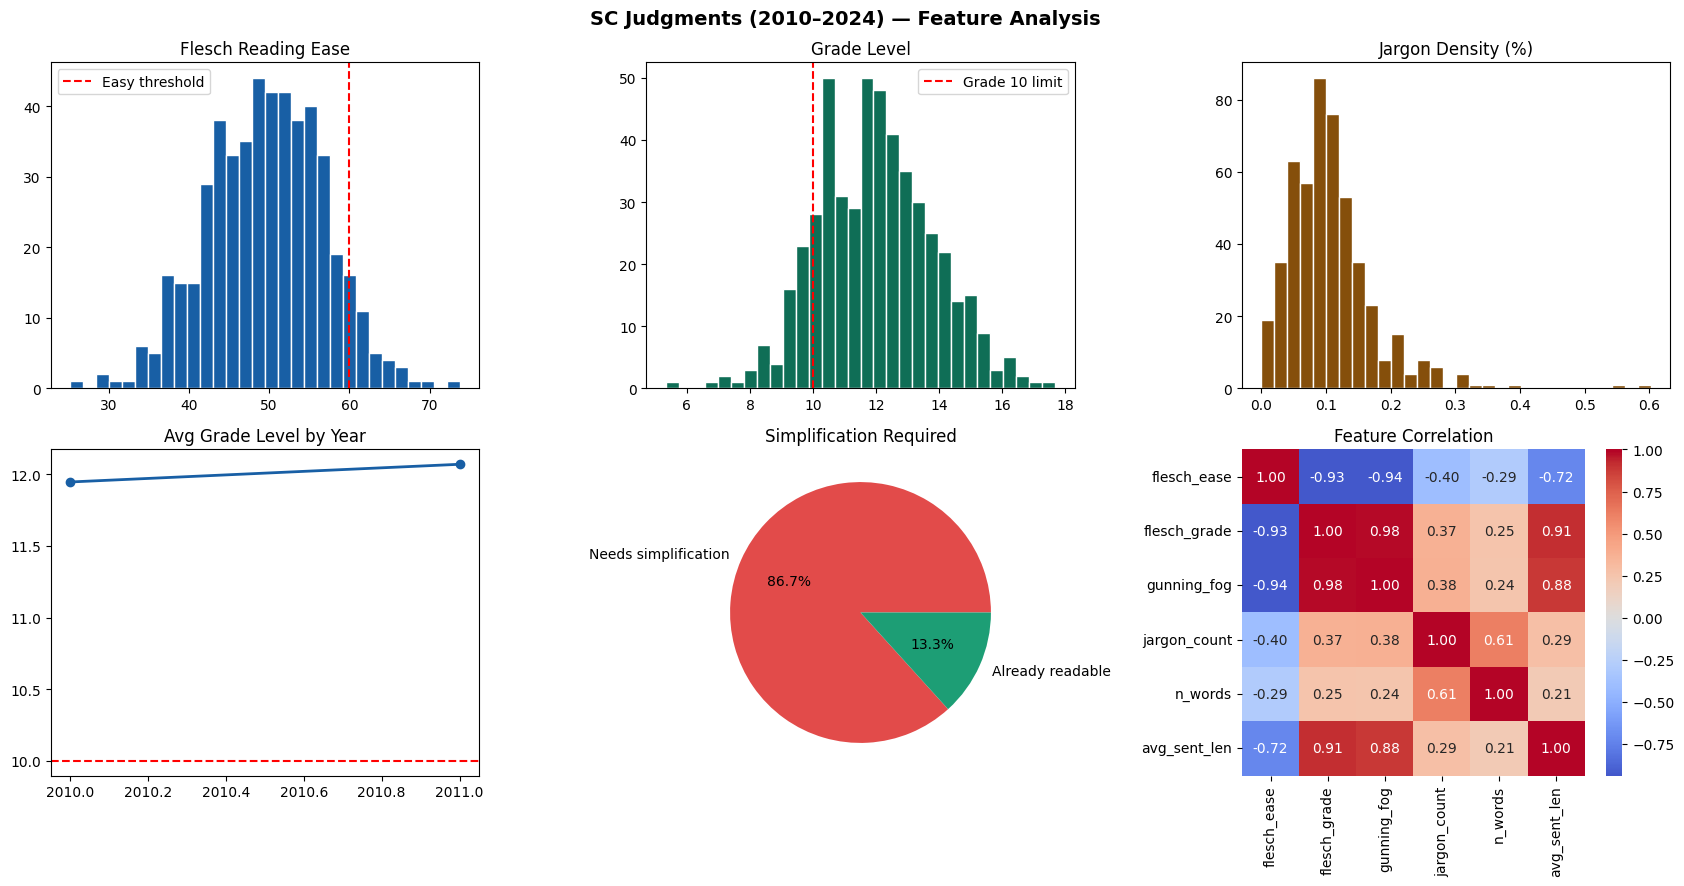

Docs needing simplification: 431 / 497


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f'{PROCESSED_DIR}/features.csv')

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('SC Judgments (2010–2024) — Feature Analysis', fontsize=14, fontweight='bold')

axes[0,0].hist(df['flesch_ease'], bins=30, color='#185FA5', edgecolor='white')
axes[0,0].axvline(60, color='red', linestyle='--', label='Easy threshold')
axes[0,0].set_title('Flesch Reading Ease'); axes[0,0].legend()

axes[0,1].hist(df['flesch_grade'], bins=30, color='#0F6E56', edgecolor='white')
axes[0,1].axvline(10, color='red', linestyle='--', label='Grade 10 limit')
axes[0,1].set_title('Grade Level'); axes[0,1].legend()

axes[0,2].hist(df['jargon_density'], bins=30, color='#854F0B', edgecolor='white')
axes[0,2].set_title('Jargon Density (%)')

if 'year' in df.columns and df['year'].notna().any():
    yearly = df.groupby('year')['flesch_grade'].mean().reset_index()
    axes[1,0].plot(yearly['year'], yearly['flesch_grade'], marker='o', color='#185FA5', linewidth=2)
    axes[1,0].axhline(10, color='red', linestyle='--')
    axes[1,0].set_title('Avg Grade Level by Year')

needs = df['needs_simplify'].value_counts()
axes[1,1].pie(needs, labels=['Needs simplification', 'Already readable'],
              colors=['#E24B4A', '#1D9E75'], autopct='%1.1f%%')
axes[1,1].set_title('Simplification Required')

corr_cols = ['flesch_ease', 'flesch_grade', 'gunning_fog', 'jargon_count', 'n_words', 'avg_sent_len']
sns.heatmap(df[corr_cols].corr(), ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm', center=0)
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Docs needing simplification: {df['needs_simplify'].sum()} / {len(df)}")

## CELL 9 — Complexity Classifier (Logistic Regression / Random Forest / Gradient Boosting)


Logistic Regression | CV F1: 0.9942 | Test Acc: 0.9900
                precision    recall  f1-score   support

      Readable       1.00      0.92      0.96        13
Needs Simplify       0.99      1.00      0.99        87

      accuracy                           0.99       100
     macro avg       0.99      0.96      0.98       100
  weighted avg       0.99      0.99      0.99       100


Random Forest | CV F1: 0.9986 | Test Acc: 0.9900
                precision    recall  f1-score   support

      Readable       1.00      0.92      0.96        13
Needs Simplify       0.99      1.00      0.99        87

      accuracy                           0.99       100
     macro avg       0.99      0.96      0.98       100
  weighted avg       0.99      0.99      0.99       100


Gradient Boosting | CV F1: 0.9971 | Test Acc: 1.0000
                precision    recall  f1-score   support

      Readable       1.00      1.00      1.00        13
Needs Simplify       1.00      1.00      1.00    

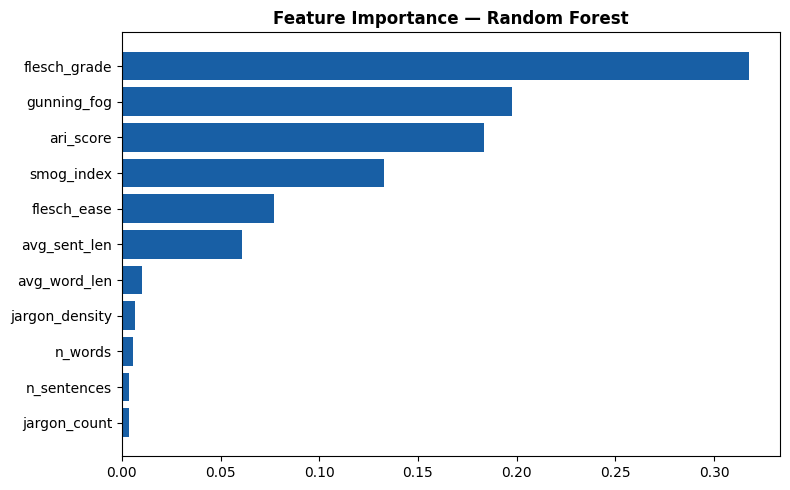

✅ Classifier and scaler saved


In [7]:
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

df = pd.read_csv(f'{PROCESSED_DIR}/features.csv')
X  = df[FEATURE_COLS].fillna(0)
y  = df['needs_simplify'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

best_model, best_score, best_name = None, 0, ''
print('=' * 55)

for name, clf in classifiers.items():
    X_tr = scaler.fit_transform(X_train) if 'Logistic' in name else X_train
    X_te = scaler.transform(X_test)      if 'Logistic' in name else X_test
    clf.fit(X_tr, y_train)
    cv  = cross_val_score(clf, X_tr, y_train, cv=5, scoring='f1').mean()
    acc = clf.score(X_te, y_test)
    print(f'\n{name} | CV F1: {cv:.4f} | Test Acc: {acc:.4f}')
    print(classification_report(y_test, clf.predict(X_te),
          target_names=['Readable', 'Needs Simplify'], zero_division=0))
    if cv > best_score:
        best_score, best_model, best_name = cv, clf, name

print(f'\n🏆 Best: {best_name} (CV F1 = {best_score:.4f})')

# feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = sorted(zip(FEATURE_COLS, best_model.feature_importances_), key=lambda x: x[1])
    labels, vals = zip(*fi)
    plt.figure(figsize=(8, 5))
    plt.barh(labels, vals, color='#185FA5')
    plt.title(f'Feature Importance — {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=120)
    plt.show()

with open(f'{MODELS_DIR}/classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open(f'{MODELS_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Classifier and scaler saved')

## CELL 10 — Load T5 model and define simplify function

In [3]:
import torch
import pandas as pd
import re
from transformers import T5ForConditionalGeneration, T5Tokenizer

def substitute_jargon(text):
    for term, plain in INDIAN_JARGON_MAP.items():
        text = re.sub(re.escape(term), plain, text, flags=re.IGNORECASE)
    return text

print('Loading T5-small model...')
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model     = T5ForConditionalGeneration.from_pretrained('t5-small')
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = model.to(device)
print(f'✅ Model loaded on: {device}')

def simplify(text, max_input=512):
    text   = substitute_jargon(text)
    prompt = 'simplify legal text: ' + text[:1500]
    inputs = tokenizer(prompt, return_tensors='pt',
                       max_length=max_input, truncation=True).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=180, num_beams=4,
            length_penalty=2.0, early_stopping=True, no_repeat_ngram_size=3
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

# quick test
df = pd.read_csv(f'{PROCESSED_DIR}/features.csv')
test_result = simplify(df['clean_text'].iloc[0])
print('\nTest simplification:')
print(test_result)

Loading T5-small model...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


✅ Model loaded on: cpu

Test simplification:
False


## CELL 11 — Fine-tune T5 on SC Judgments

In [7]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch

class SCDataset(Dataset):
    def __init__(self, texts, tokenizer):
        self.data = []
        for text in texts:
            words   = text.split()
            source  = 'simplify legal text: ' + ' '.join(words[:400])
            target  = ' '.join(words[:60])
            src_enc = tokenizer(source, max_length=MAX_SRC_LEN, truncation=True,
                                padding='max_length', return_tensors='pt')
            tgt_enc = tokenizer(target, max_length=MAX_TGT_LEN, truncation=True,
                                padding='max_length', return_tensors='pt')
            labels  = tgt_enc['input_ids'].squeeze()
            labels[labels == tokenizer.pad_token_id] = -100
            self.data.append({
                'input_ids'     : src_enc['input_ids'].squeeze(),
                'attention_mask': src_enc['attention_mask'].squeeze(),
                'labels'        : labels,
            })
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

split       = int(len(df) * TRAIN_SPLIT)
train_texts = df['clean_text'].tolist()[:split]
val_texts   = df['clean_text'].tolist()[split:]
print(f'Train: {len(train_texts)} | Val: {len(val_texts)}')

train_loader = DataLoader(SCDataset(train_texts, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SCDataset(val_texts,   tokenizer), batch_size=BATCH_SIZE)

optimizer = AdamW(model.parameters(), lr=LR)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=50,
    num_training_steps=len(train_loader) * EPOCHS
)

train_losses, val_losses = [], []
print(f'\nFine-tuning for {EPOCHS} epochs...\n')

for epoch in range(EPOCHS):
    model.train()
    t_loss = 0
    for batch in train_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        loss   = model(**batch).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        t_loss += loss.item()

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            v_loss += model(**batch).loss.item()

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    train_losses.append(avg_t)
    val_losses.append(avg_v)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train: {avg_t:.4f} | Val: {avg_v:.4f}')

Train: 397 | Val: 100

Fine-tuning for 3 epochs...

Epoch 1/3 | Train: 0.3642 | Val: 0.0473
Epoch 2/3 | Train: 0.0537 | Val: 0.0405
Epoch 3/3 | Train: 0.0420 | Val: 0.0419


## CELL 12 — Evaluation (ROUGE + readability before/after)

In [6]:
from rouge_score import rouge_scorer as rouge_module
import pandas as pd
import textstat
import re
import spacy
import subprocess
import sys

# Load spacy model
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])
except OSError:
    print("Downloading spacy model...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])

rouge_sc = rouge_module.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def get_reference(text, n=3):
    doc   = nlp(text[:5000])
    sents = [s.text.strip() for s in doc.sents if len(s.text.strip()) > 20]
    return ' '.join(sents[:n])

df = pd.read_csv(f'{PROCESSED_DIR}/features.csv')
model.eval()

results = []
print(f"{'Doc':<5} {'Yr':>5} {'B.Grade':>8} {'A.Grade':>8} {'B.Ease':>8} {'A.Ease':>8} {'R1':>7} {'Status':>10}")
print('-' * 70)

for i in range(min(20, len(df))):
    row        = df.iloc[i]
    simplified = simplify(str(row['clean_text']))
    a_grade    = textstat.flesch_kincaid_grade(simplified)
    a_ease     = textstat.flesch_reading_ease(simplified)
    ref        = get_reference(str(row['clean_text']))
    sc         = rouge_sc.score(ref, simplified)

    results.append({
        'doc_id'      : i + 1,
        'year'        : row.get('year', ''),
        'original'    : str(row['clean_text'])[:300],
        'simplified'  : simplified,
        'before_grade': row['flesch_grade'],
        'after_grade' : round(a_grade, 1),
        'before_ease' : row['flesch_ease'],
        'after_ease'  : round(a_ease, 1),
        'rouge1'      : round(sc['rouge1'].fmeasure, 4),
        'rouge2'      : round(sc['rouge2'].fmeasure, 4),
        'rougeL'      : round(sc['rougeL'].fmeasure, 4),
        'improved'    : a_ease > row['flesch_ease'],
    })

    status = 'Improved' if a_ease > row['flesch_ease'] else 'Check'
    print(f"Doc {i+1:<3} {str(row.get('year',''))[:4]:>5} "
          f"{row['flesch_grade']:>8.1f} {a_grade:>8.1f} "
          f"{row['flesch_ease']:>8.1f} {a_ease:>8.1f} "
          f"{sc['rouge1'].fmeasure:>7.3f} {status:>10}")

results_df = pd.DataFrame(results)
results_df.to_csv(f'{PROCESSED_DIR}/eval_results.csv', index=False)

print(f"\n✅ Improved    : {results_df.improved.sum()}/{len(results_df)}")
print(f"   Avg ROUGE-1 : {results_df.rouge1.mean():.4f}")
print(f"   Avg grade ↓ : {(results_df.before_grade - results_df.after_grade).mean():.2f}")

Doc      Yr  B.Grade  A.Grade   B.Ease   A.Ease      R1     Status
----------------------------------------------------------------------
Doc 1    2010     11.7     -3.4     51.2    121.2   0.000   Improved
Doc 2    2010      9.1     -3.4     60.2    121.2   0.000   Improved
Doc 3    2010     12.8     10.5     38.9     35.6   0.410      Check
Doc 4    2010     12.2      9.5     52.9     53.4   0.141   Improved
Doc 5    2010     14.3      9.6     41.5     59.5   0.632   Improved
Doc 6    2010     13.3      9.2     45.9     62.9   0.294   Improved
Doc 7    2010     13.2      6.9     50.5     61.4   0.091   Improved
Doc 8    2010     13.8     18.4     40.2     26.9   0.000      Check
Doc 9    2010     11.1      8.4     49.8     45.6   0.141      Check
Doc 10   2010     14.6      6.3     37.5     71.8   0.281   Improved
Doc 11   2010      9.3     -3.4     58.6    121.2   0.000   Improved
Doc 12   2010     14.3      4.2     41.4     76.6   0.519   Improved
Doc 13   2010      8.5      7.0   

## CELL 13 — Results Visualisation

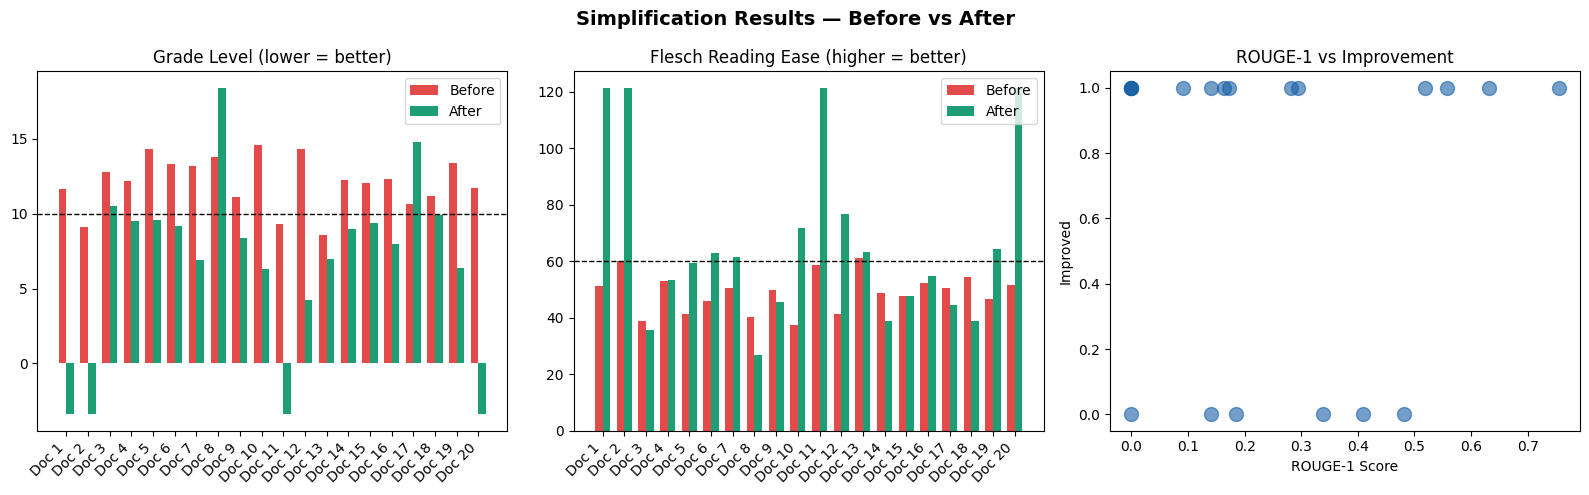

✅ Results saved → d:\_SEMESTER - 2 GIS\Natural Language Processing\legal_nlp\data\outputs/simplification_results.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv(f'{PROCESSED_DIR}/eval_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Simplification Results — Before vs After', fontsize=14, fontweight='bold')

docs = [f'Doc {i+1}' for i in range(len(results_df))]
x    = np.arange(len(docs))
w    = 0.35

axes[0].bar(x - w/2, results_df.before_grade, w, label='Before', color='#E24B4A')
axes[0].bar(x + w/2, results_df.after_grade,  w, label='After',  color='#1D9E75')
axes[0].axhline(10, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Grade Level (lower = better)')
axes[0].set_xticks(x); axes[0].set_xticklabels(docs, rotation=45, ha='right')
axes[0].legend()

axes[1].bar(x - w/2, results_df.before_ease, w, label='Before', color='#E24B4A')
axes[1].bar(x + w/2, results_df.after_ease,  w, label='After',  color='#1D9E75')
axes[1].axhline(60, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Flesch Reading Ease (higher = better)')
axes[1].set_xticks(x); axes[1].set_xticklabels(docs, rotation=45, ha='right')
axes[1].legend()

axes[2].scatter(results_df.rouge1, results_df.improved.astype(int), s=100, alpha=0.6, color='#185FA5')
axes[2].set_title('ROUGE-1 vs Improvement')
axes[2].set_xlabel('ROUGE-1 Score')
axes[2].set_ylabel('Improved')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/simplification_results.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Results saved → {OUTPUT_DIR}/simplification_results.png")

## CELL 14 — Gradio Web App (Deployment)

In [9]:
import gradio as gr
import pickle

with open(f'{MODELS_DIR}/classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

def app_pipeline(user_text):
    if not user_text or len(user_text.strip()) < 50:
        return 'Please paste a judgment (min 50 characters).', '', '', ''

    feats    = extract_features(user_text)
    jargon_l = feats.pop('jargon_list', [])
    needs    = clf.predict(np.array([[feats[c] for c in FEATURE_COLS]]))[0]

    before = (
        f'**Before**\n'
        f'- Grade level  : {feats["flesch_grade"]} {"(complex)" if feats["flesch_grade"]>10 else "(OK)"}\n'
        f'- Reading ease : {feats["flesch_ease"]}\n'
        f'- Jargon terms : {feats["jargon_count"]} detected\n'
        f'- Action       : {"Simplifying" if needs else "Already readable"}'
    )

    result      = simplify(user_text) if needs else user_text
    after_grade = textstat.flesch_kincaid_grade(result)
    after_ease  = textstat.flesch_reading_ease(result)

    after = (
        f'**After**\n'
        f'- Grade level  : {round(after_grade,1)} {"(improved)" if after_grade < feats["flesch_grade"] else ""}\n'
        f'- Reading ease : {round(after_ease,1)} {"(improved)" if after_ease > feats["flesch_ease"] else ""}'
    )

    jargon_out = '**Legal terms explained:**\n' + '\n'.join(
        f'- `{j}` → {INDIAN_JARGON_MAP.get(j, "simplified")}'
        for j in jargon_l
    ) if jargon_l else 'No major jargon detected.'

    return result, before, after, jargon_out

demo = gr.Interface(
    fn=app_pipeline,
    inputs=gr.Textbox(
        label='Paste Supreme Court judgment',
        placeholder='e.g. The petitioner filed a Special Leave Petition inter alia challenging...',
        lines=10
    ),
    outputs=[
        gr.Textbox(label='Plain-English output', lines=6),
        gr.Markdown(label='Before'),
        gr.Markdown(label='After'),
        gr.Markdown(label='Jargon explained'),
    ],
    title='Indian SC Judgment Simplifier',
    description='Paste any Supreme Court of India judgment. Get a plain-English version readable by any citizen aged 18+.',
    examples=[[
        'The petitioner filed a Special Leave Petition inter alia challenging the order '
        'passed by the High Court. Prima facie the respondent has no locus standi. '
        'Notwithstanding the provisions of Article 226, the suo motu proceedings are '
        'ultra vires the jurisdiction. The ratio decidendi of the aforesaid judgment '
        'pursuant to Section 34 is res judicata.'
    ]],
    theme=gr.themes.Soft()
)

demo.launch(share=True)  # share=True gives a public URL from Colab

ModuleNotFoundError: No module named 'gradio'